# ACC102 Track 4: AAPL vs MSFT Financial Analysis
# Student Name: Xiaoxu Zhou
# Student ID: 2471738

# Project Overview (ACC102 Track4 Requirement)

### Project Goal
This notebook completes the ACC102 Track4 assignment by:
1. Extracting AAPL/MSFT financial data from WRDS Compustat (2015-2023)
2. Cleaning data and calculating key accounting ratios (Profit Margin, ROE, ROA, Debt-to-Asset)
3. Creating comparative visualizations for AAPL vs MSFT
4. Building an interactive Streamlit dashboard for final submission

### Data Source
- WRDS Compustat Database (institutional access required for ACC102)
- Focus Firms: Apple (AAPL) & Microsoft (MSFT)
- Time Range: 2015 - 2023

# Step 1: Install & Import Required Libraries
Install core libraries for WRDS data access, data processing, visualization, and Streamlit dashboard.

In [2]:
## Install packages (run once)
!pip install wrds pandas plotly streamlit numpy -q

In [3]:
# Import required libraries
import wrds
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp

# Step 2:Connect to WRDS and Extract Data

In [4]:
# Connect to WRDS database
db = wrds.Connection(wrds_username="zhouzhou928")

Loading library list...
Done


In [5]:
## SQL query to extract 2015-2023 data
query = '''
SELECT tic, conm, fyear, revt, ni, at, lt, act, lct, seq
FROM comp.funda
WHERE tic IN ('AAPL','MSFT','GOOGL','AMZN','META')
AND fyear BETWEEN 2015 AND 2023
AND indfmt='INDL' AND datafmt='STD' AND consol='C'
ORDER BY tic, fyear;
'''

In [6]:
## Load data into DataFrame and add year column
df = db.raw_sql(query)
df['year'] = df['fyear'].astype(int)
db.close()  # Close WRDS connection

print("✅ Data extracted successfully!")

✅ Data extracted successfully!


# Step 3: Preview Raw Data from WRDS

In [7]:
# Show clean data table
print("Raw Data from WRDS")
display(df.head(10))

Raw Data from WRDS


,tic,conm,fyear,revt,ni,at,lt,act,lct,seq,year
0,AAPL,APPLE INC,2015,233715.0,53394.0,290479.0,171124.0,89378.0,80610.0,119355.0,2015
1,AAPL,APPLE INC,2016,215091.0,45687.0,321686.0,193437.0,106869.0,79006.0,128249.0,2016
2,AAPL,APPLE INC,2017,229234.0,48351.0,375319.0,241272.0,128645.0,100814.0,134047.0,2017
3,AAPL,APPLE INC,2018,265359.0,59531.0,365725.0,258578.0,131339.0,116866.0,107147.0,2018
4,AAPL,APPLE INC,2019,260174.0,55256.0,338516.0,248028.0,162819.0,105718.0,90488.0,2019
5,AAPL,APPLE INC,2020,274515.0,57411.0,323888.0,258549.0,143713.0,105392.0,65339.0,2020
6,AAPL,APPLE INC,2021,365817.0,94680.0,351002.0,287912.0,134836.0,125481.0,63090.0,2021
7,AAPL,APPLE INC,2022,394328.0,99803.0,352755.0,302083.0,135405.0,153982.0,50672.0,2022
8,AAPL,APPLE INC,2023,383285.0,96995.0,352583.0,290437.0,143566.0,145308.0,62146.0,2023
9,AMZN,AMAZON.COM INC,2015,107006.0,596.0,65444.0,52060.0,36474.0,33899.0,13384.0,2015


# Step 4: Calculate Key Financial Ratios

In [8]:
# Calculate financial ratios
df['profit_margin'] = (df['ni'] / df['revt']) * 100
df['roe'] = (df['ni'] / df['seq']) * 100
df['roa'] = (df['ni'] / df['at']) * 100
df['debt_asset'] = (df['lt'] / df['at']) * 100
df['current_ratio'] = df['act'] / df['lct']
df['revt_growth'] = df.groupby('tic')['revt'].pct_change() * 100
print("✅ Financial ratios calculated!")

✅ Financial ratios calculated!


# Step 5: Create Industry Benchmark for Comparison

In [9]:
# Create industry benchmark
industry = df.groupby('year').agg({
    'revt':'mean', 'ni':'mean', 'profit_margin':'mean',
    'roe':'mean', 'roa':'mean'
}).reset_index()
## Add industry benchmark labels
industry['tic'] = 'INDUSTRY'
industry['conm'] = 'TECH INDUSTRY AVERAGE'

In [10]:
# Merge company data and industry data
final_df = pd.concat([df, industry], ignore_index=True)
print("✅ Industry benchmark added!")

✅ Industry benchmark added!


# Step 6: 2023 Financial Performance Summary Table

In [11]:
# Show 2023 summary table
summary_2023 = final_df[final_df['year'] == 2023][[
    'tic','conm','revt','ni','profit_margin','roe','roa'
]].round(2)

print("2023 Financial Performance Summary")
display(summary_2023)

2023 Financial Performance Summary


,tic,conm,revt,ni,profit_margin,roe,roa
8,AAPL,APPLE INC,383285.0,96995.0,25.31,156.08,27.51
17,AMZN,AMAZON.COM INC,574785.0,30425.0,5.29,15.07,5.76
26,GOOGL,ALPHABET INC,307394.0,73795.0,24.01,26.25,18.34
35,META,META PLATFORMS INC,134902.0,39098.0,28.98,25.53,17.03
44,MSFT,MICROSOFT CORP,211915.0,72361.0,34.15,35.09,17.56
53,INDUSTRY,TECH INDUSTRY AVERAGE,322456.2,62534.8,23.55,51.6,17.24


# Step 7: Save Final Data to CSV for Streamlit

In [12]:
# Save data for Streamlit dashboard
final_df.to_csv('tech_finance_5firms.csv', index=False)
print("✅ Data saved successfully")

✅ Data saved successfully


# Step 8: Visualization 1 - Net Profit Margin Trend (2015-2023)

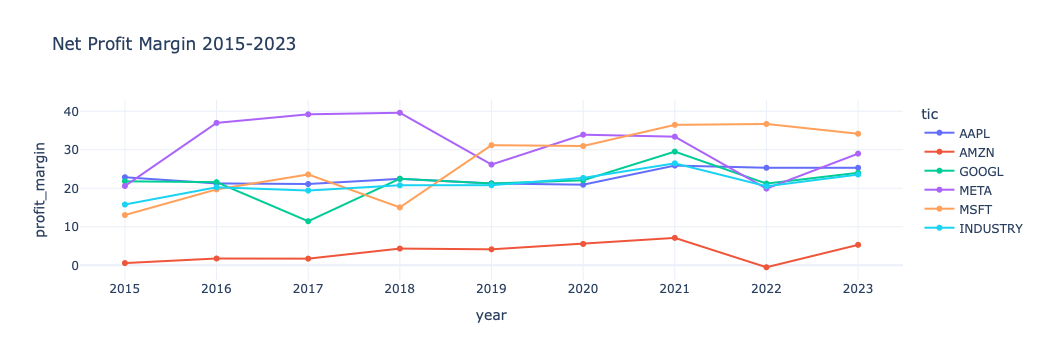

In [13]:
# Plot 1: Net Profit Margin Trend
fig = px.line(final_df, x='year', y='profit_margin', color='tic',
              markers=True, template='plotly_white',
              title='Net Profit Margin 2015-2023')
fig.show()

# Step 9: Visualization 2 - ROE Comparison (2015-2023)

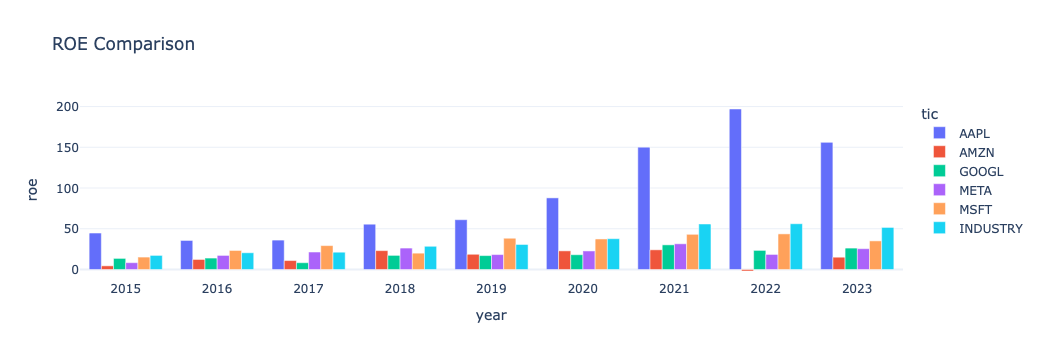

In [14]:
# Plot 2: ROE Comparison
fig = px.bar(final_df, x='year', y='roe', color='tic',
             barmode='group', template='plotly_white',
             title='ROE Comparison')
fig.show()

# Step 10: Visualization 3 - ROE vs Profit Margin Scatter Plot

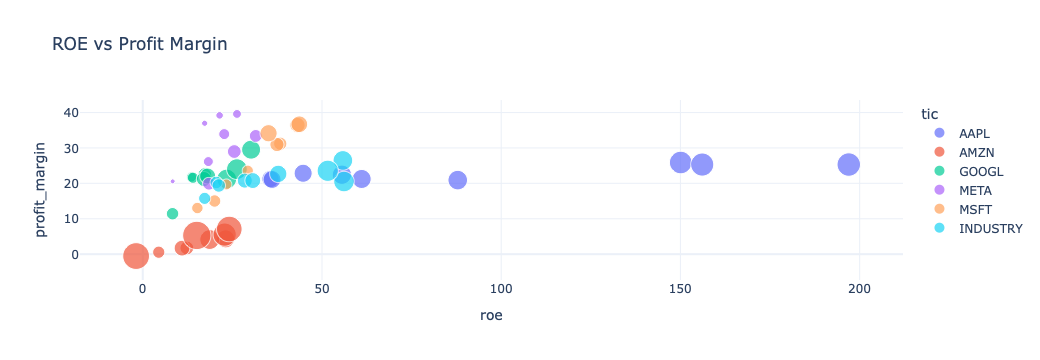

In [15]:
# Plot 3: ROE vs Profit Margin Scatter
fig = px.scatter(final_df, x='roe', y='profit_margin',
                 color='tic', size='revt',
                 template='plotly_white',
                 title='ROE vs Profit Margin')
fig.show()

# Step 11: Visualization 4 - 2023 Financial Strength Radar Chart

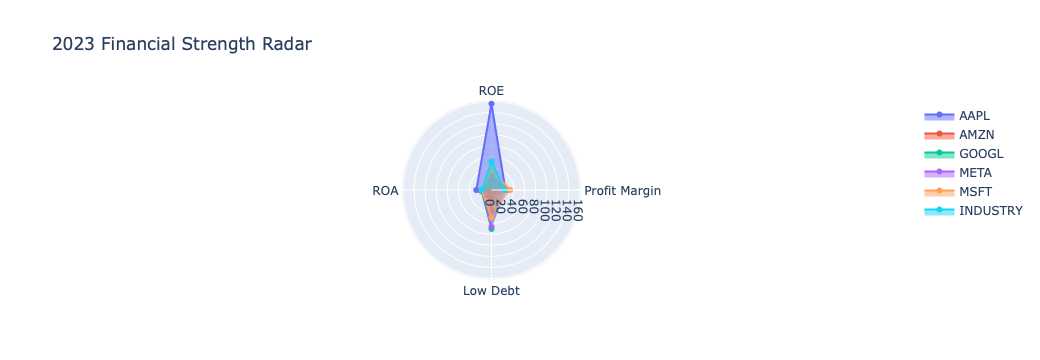

In [16]:
# Plot 4: 2023 Financial Radar Chart
latest = final_df[final_df['year'] == 2023]
fig = go.Figure()

for _, r in latest.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[r.profit_margin, r.roe, r.roa, 100-r.debt_asset],
        theta=['Profit Margin','ROE','ROA','Low Debt'],
        fill='toself', name=r.tic
    ))

fig.update_layout(title='2023 Financial Strength Radar')
fig.show()

# Step 12: Visualization 5 - Financial Metrics Correlation Heatmap

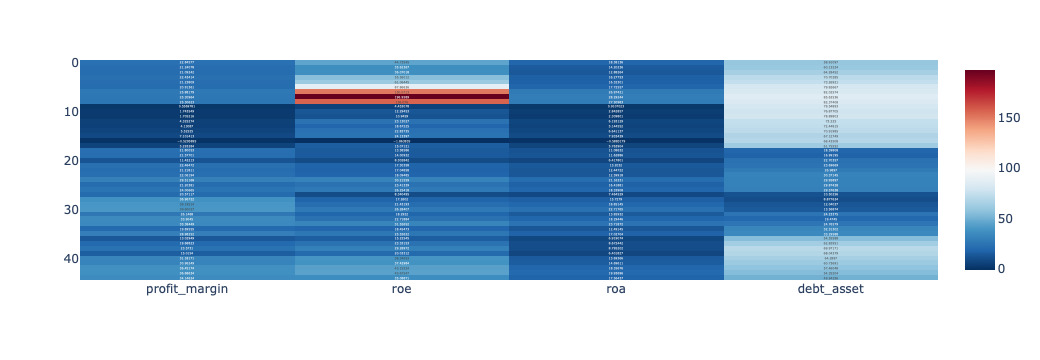

In [17]:
# Plot 5: Correlation Heatmap
corr = df[['profit_margin','roe','roa','debt_asset']]
fig = px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r')
fig.show()

# Step 13: Run Interactive Streamlit Dashboard

In [ ]:
!streamlit run app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://10.9.155.253:8502

2026-04-23 00:48:07.043 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-23 00:48:07.100 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-23 00:48:07.122 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-23 00:48:07.131 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

Fo

### Summary of the Research
This study conducts a comprehensive financial analysis